### Question 3

Image shape: (768, 1024, 3)
Flag shape: (150, 225, 3)
Selected Points: [(148, 207), (522, 290), (519, 464), (135, 447)]
Homographic Matrix: 
[[ 2.55882186e+00 -1.08142247e-01  1.48000000e+02]
 [ 8.64524047e-01  1.54155615e+00  2.07000000e+02]
 [ 1.70340804e-03 -1.54769816e-04  1.00000000e+00]]


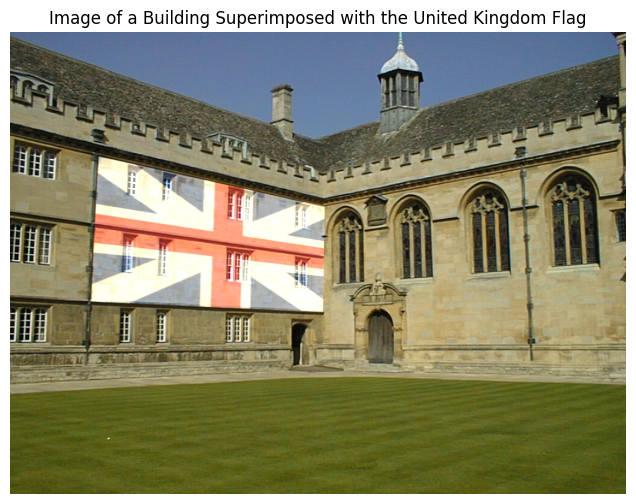

In [15]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ---- mouse callback ----
clicked_points = []
def point_selection(action, x, y, flags, param):
    global clicked_points, base_disp
    if action == cv.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
        clicked_points.append((x, y))
        cv.circle(base_disp, (x, y), 5, (0, 0, 255), -1)
        cv.imshow('Base Image', base_disp)

# ---- load images (keep alpha if PNG) ----
base_img  = cv.imread('Building.jpg', cv.IMREAD_COLOR)
adding_img = cv.imread('flag.png', cv.IMREAD_UNCHANGED)
if base_img is None or adding_img is None:
    raise FileNotFoundError("Check paths: 'Building.jpg' / 'flag.png'")

# ---- show & pick 4 points on base image (order: TL, TR, BR, BL) ----
base_disp = base_img.copy()
cv.namedWindow('Base Image', cv.WINDOW_AUTOSIZE)
cv.imshow('Base Image', base_disp)
cv.setMouseCallback('Base Image', point_selection)
while len(clicked_points) < 4:
    if cv.waitKey(10) == 27:  # ESC to abort
        break
cv.destroyAllWindows()

# ---- prepare source/destination quads ----
dst = np.array(clicked_points, dtype=np.float32)                       # TL,TR,BR,BL
h2, w2 = adding_img.shape[:2]
src = np.array([[0,0],[w2-1,0],[w2-1,h2-1],[0,h2-1]], dtype=np.float32)

print("Image shape:", base_img.shape)
print("Flag shape:", adding_img.shape)
print("Selected Points:", clicked_points)

# ---- homography ----
H = cv.getPerspectiveTransform(src, dst)
print('Homographic Matrix: ')
print(H)

# Warping the adding image with the homography
warped_img = cv.warpPerspective(adding_img, H, (base_img.shape[1], base_img.shape[0]))

# Superimposing the warped image with the base image
supimp_img = cv.addWeighted(base_img, 1, warped_img, 0.5, 0)

plt.figure(figsize=(12,6))
plt.imshow(cv.cvtColor(supimp_img, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Image of a Building Superimposed with the United Kingdom Flag')
plt.show()



### Question 4

Detected 2674 and 3923 SIFT keypoints.
Good matches after ratio test: 87
RANSAC inliers: 7 / 87
Estimated Homography:
 [[ 1.19825317e+00 -1.53235190e+00  1.27593892e+02]
 [ 3.85234520e+00 -4.81475806e+00  3.50419853e+02]
 [ 1.06306045e-02 -1.33381692e-02  1.00000000e+00]]


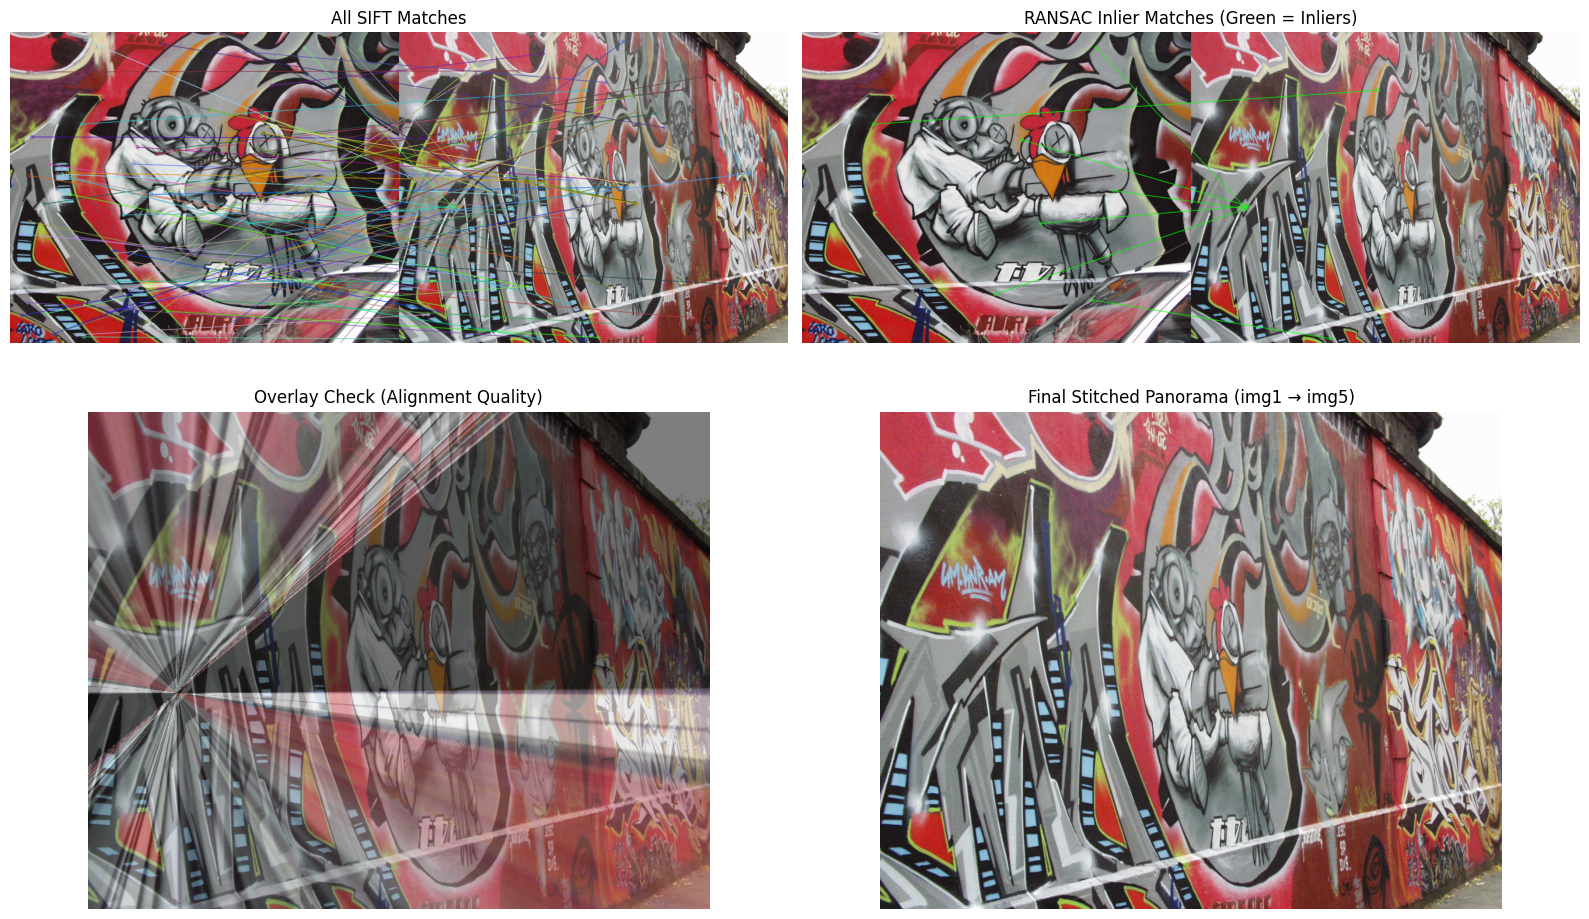


===== Summary Statistics =====
Detected features: 2674 (img1), 3923 (img5)
Good matches: 87
RANSAC inliers: 7 (8.0% inlier ratio)


In [11]:


import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1 | Load images ------------------------------------------------------
img1 = cv.imread("img1.ppm")   # source
img5 = cv.imread("img5.ppm")   # reference
if img1 is None or img5 is None:
    raise FileNotFoundError("Graffiti images not found. Place img1.ppm & img5.ppm in /images/.")

# --- Step 2 | Detect & describe SIFT features ---------------------------------
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(cv.cvtColor(img1, cv.COLOR_BGR2GRAY), None)
kp5, des5 = sift.detectAndCompute(cv.cvtColor(img5, cv.COLOR_BGR2GRAY), None)
print(f"Detected {len(kp1)} and {len(kp5)} SIFT keypoints.")

# --- Step 3 | Match descriptors (Lowe’s ratio test) ---------------------------
bf = cv.BFMatcher()
matches = bf.knnMatch(des1, des5, k=2)
good_matches = [m for m, n in matches if m.distance < 0.75 * n.distance]
print(f"Good matches after ratio test: {len(good_matches)}")

pts1 = np.float32([kp1[m.queryIdx].pt for m in good_matches])
pts5 = np.float32([kp5[m.trainIdx].pt for m in good_matches])

# --- Step 4 | Custom RANSAC Homography estimation -----------------------------
def ransac_homography(src_pts, dst_pts, thresh=4.0, max_iter=2000):
    best_H, best_inliers = None, []
    n = src_pts.shape[0]
    for _ in range(max_iter):
        idx = np.random.choice(n, 4, replace=False)
        H, _ = cv.findHomography(src_pts[idx], dst_pts[idx], 0)
        if H is None:
            continue
        proj = cv.perspectiveTransform(src_pts.reshape(-1, 1, 2), H).reshape(-1, 2)
        errors = np.linalg.norm(dst_pts - proj, axis=1)
        inliers = np.where(errors < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers, best_H = inliers, H
    return best_H, best_inliers

H, inliers = ransac_homography(pts1, pts5)
print(f"RANSAC inliers: {len(inliers)} / {len(good_matches)}")
print("Estimated Homography:\n", H)

# --- Step 5 | Visualize matches and RANSAC inliers ----------------------------
inlier_mask = np.zeros(len(good_matches), dtype=bool)
inlier_mask[inliers] = True
inlier_matches = [m for i, m in enumerate(good_matches) if inlier_mask[i]]

img_matches_all = cv.drawMatches(img1, kp1, img5, kp5, good_matches[:80], None,
                                 flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
img_matches_in = cv.drawMatches(img1, kp1, img5, kp5, inlier_matches[:80], None,
                                matchColor=(0,255,0),
                                singlePointColor=(255,0,0),
                                flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# --- Step 6 | Warp img1 onto img5 (robust bounding box method) ---------------
h1, w1 = img1.shape[:2];  h5, w5 = img5.shape[:2]
corners1 = np.float32([[0,0],[w1,0],[w1,h1],[0,h1]]).reshape(-1,1,2)
warp_corners = cv.perspectiveTransform(corners1, H)
corners5 = np.float32([[0,0],[w5,0],[w5,h5],[0,h5]]).reshape(-1,1,2)
all_corners = np.concatenate((warp_corners, corners5), axis=0)
[x_min,y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
[x_max,y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)
tx, ty = -x_min, -y_min
T = np.array([[1,0,tx],[0,1,ty],[0,0,1]])
panorama = cv.warpPerspective(img1, T @ H, (x_max - x_min, y_max - y_min))
panorama[ty:ty + h5, tx:tx + w5] = img5

# --- Step 7 | Additional output views ----------------------------------------
# Overlay img1 on img5 using estimated H (for quality check)
overlay = cv.warpPerspective(img1, H, (w5, h5))
blend = cv.addWeighted(img5, 0.5, overlay, 0.5, 0)

# --- Step 8 | Display comprehensive results ----------------------------------
plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plt.imshow(cv.cvtColor(img_matches_all, cv.COLOR_BGR2RGB))
plt.title("All SIFT Matches"); plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(cv.cvtColor(img_matches_in, cv.COLOR_BGR2RGB))
plt.title("RANSAC Inlier Matches (Green = Inliers)"); plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(cv.cvtColor(blend, cv.COLOR_BGR2RGB))
plt.title("Overlay Check (Alignment Quality)"); plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(cv.cvtColor(panorama, cv.COLOR_BGR2RGB))
plt.title("Final Stitched Panorama (img1 → img5)"); plt.axis("off")

plt.tight_layout()
plt.show()

# --- Step 9 | Report numeric summary -----------------------------------------
print("\n===== Summary Statistics =====")
print(f"Detected features: {len(kp1)} (img1), {len(kp5)} (img5)")
print(f"Good matches: {len(good_matches)}")
print(f"RANSAC inliers: {len(inliers)} ({len(inliers)/len(good_matches)*100:.1f}% inlier ratio)")